# Exploratory Data Analysis - SBA 7(a) Loan Default Prediction

Goal: understand the SBA 7(a) loan dataset from FY2010-FY2019 and prepare for a binary classification task:
- Paid in full
- Charged off / defaulted

This notebook focuses on:
1. Dataset size and column types
2. Target variable definition
3. Missing values
4. Leakage-prone fields
5. Numerical and categorical feature distributions
6. Initial modeling decisions

In [71]:
import pandas as pd
df = pd.read_csv("../data/raw/FOIA_7a_FY2010_FY2019_asof_260630.csv", low_memory=False)

In [72]:
df.shape

(545751, 42)

In [73]:
print(df.columns.tolist())

['AsOfDate', 'Program', 'LocationID', 'BorrName', 'BorrStreet', 'BorrCity', 'BorrState', 'BorrZip', 'BankName', 'BankFDICNumber', 'BankNCUANumber', 'BankStreet', 'BankCity', 'BankState', 'BankZip', 'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalDate', 'ApprovalFY', 'FirstDisbursementDate', 'ProcessingMethod', 'InitialInterestRate', 'FixedorVariableInterestInd', 'TermInMonths', 'NaicsCode', 'NaicsDescription', 'FranchiseCode', 'FranchiseName', 'ProjectCounty', 'ProjectState', 'SBADistrictOffice', 'CongressionalDistrict', 'BusinessType', 'BusinessAge', 'LoanStatus', 'PaidInFullDate', 'ChargeOffDate', 'GrossChargeOffAmount', 'RevolverStatus', 'JobsSupported', 'CollateralInd', 'SoldSecMrktInd']


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545751 entries, 0 to 545750
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AsOfDate                    545751 non-null  str    
 1   Program                     545751 non-null  str    
 2   LocationID                  545750 non-null  float64
 3   BorrName                    545721 non-null  str    
 4   BorrStreet                  545751 non-null  str    
 5   BorrCity                    545751 non-null  str    
 6   BorrState                   545751 non-null  str    
 7   BorrZip                     545751 non-null  int64  
 8   BankName                    545750 non-null  str    
 9   BankFDICNumber              506442 non-null  float64
 10  BankNCUANumber              17691 non-null   float64
 11  BankStreet                  545750 non-null  str    
 12  BankCity                    545750 non-null  str    
 13  BankState                

In [75]:
df.head(10)

,AsOfDate,Program,LocationID,BorrName,BorrStreet,BorrCity,BorrState,BorrZip,BankName,BankFDICNumber,...,BusinessType,BusinessAge,LoanStatus,PaidInFullDate,ChargeOffDate,GrossChargeOffAmount,RevolverStatus,JobsSupported,CollateralInd,SoldSecMrktInd
0,2026-06-30,7A,72188.0,Square Burger LLC,115 Kentucky Street,McKinney,TX,75069,American Bank of Commerce,18609.0,...,CORPORATION,Unanswered,P I F,2014-07-31,NaN,0.0,N,18.0,Y,NaN
1,2026-06-30,7A,455644.0,Dr. Jeffrey Bacia and Dr. Louis Sardenga DBA P...,2608 Powers Drive,Orlando,FL,32818,Live Oak Banking Company,58665.0,...,PARTNERSHIP,"Existing, 5 or more years",P I F,2017-02-28,NaN,0.0,N,10.0,N,Y
2,2026-06-30,7A,57328.0,Rocking Rodneys Ice House LLC,285 McReynolds Ranch Rd.,Burnet,TX,78611,The Huntington National Bank,6560.0,...,CORPORATION,Less than 4 years old but at least 3,P I F,2012-05-31,NaN,0.0,N,4.0,N,NaN
3,2026-06-30,7A,57328.0,Rfl Enterprises Of Michigan Inc,41920 Hayes Rd.,CLINTON TOWNSHIP,MI,48038,The Huntington National Bank,6560.0,...,CORPORATION,"Startup, Loan Funds will Open Business",P I F,2014-12-31,NaN,0.0,N,48.0,Y,NaN
4,2026-06-30,7A,436696.0,IL Entity to be established,615 N. Cedar,Shelbyville,IL,62565,OakStar Bank,58115.0,...,CORPORATION,"New, Less than 1 Year old",CANCLD,NaN,NaN,0.0,N,0.0,Y,NaN
5,2026-06-30,7A,56102.0,"Buzyniski Electric, Inc.",1627 Phillips Road,APPLETON,NY,14008,KeyBank National Association,17534.0,...,CORPORATION,"Existing, 5 or more years",P I F,2017-12-31,NaN,0.0,Y,4.0,Y,NaN
6,2026-06-30,7A,35377.0,WATERSMEET TROUT HATCHERY & FISH FARM LLC,E25640 OLD US 2 HWY,WATERSMEET,MI,49969,The Miners State Bank,10928.0,...,CORPORATION,Less than 3 years old but at least 2,EXEMPT,NaN,NaN,0.0,N,4.0,Y,NaN
7,2026-06-30,7A,45718.0,Gayla D. Cowart DBA Cowart Insurance Agency,102 Comanche,CARLSBAD,NM,88220,First American Bank,2240.0,...,INDIVIDUAL,Less than 3 years old but at least 2,CANCLD,NaN,NaN,0.0,N,2.0,Y,NaN
8,2026-06-30,7A,75939.0,Green Construction LLC,926 North 22nd Street,Manitowoc,WI,54220,Associated Bank National Association,5296.0,...,CORPORATION,"New, Less than 1 Year old",P I F,2011-10-31,NaN,0.0,N,2.0,N,NaN
9,2026-06-30,7A,36814.0,Pohl Creek Logging Inc,31822 E Bass Lake Road,Grand Rapids,MN,55744,Park State Bank,8851.0,...,CORPORATION,"Existing, 5 or more years",P I F,2013-08-31,NaN,0.0,N,2.0,Y,NaN


In [76]:
df.describe()

,LocationID,BorrZip,BankFDICNumber,BankNCUANumber,GrossApproval,SBAGuaranteedApproval,ApprovalFY,InitialInterestRate,TermInMonths,NaicsCode,CongressionalDistrict,GrossChargeOffAmount,JobsSupported
count,545750.000000,545751.000000,506442.000000,17691.000000,5.457510e+05,5.457510e+05,545751.000000,545751.000000,545751.000000,545749.000000,545722.000000,5.457510e+05,545749.000000
mean,100967.006148,52238.503066,17387.442268,42244.829857,3.773959e+05,2.800876e+05,2014.724823,6.531549,121.342211,524388.681610,9.378992,9.657123e+03,10.723998
std,124772.479776,30828.645046,17992.917652,25695.470294,6.722855e+05,5.168764e+05,2.812685,1.559408,79.772135,175611.654444,10.662284,8.273423e+04,20.531737
min,20.000000,601.000000,35.000000,28.000000,1.000000e+03,5.000000e+02,2010.000000,0.000000,0.000000,111110.000000,0.000000,0.000000e+00,0.000000
25%,32987.000000,27616.000000,3890.000000,24563.000000,4.000000e+04,2.250000e+04,2012.000000,5.500000,84.000000,424950.000000,2.000000,0.000000e+00,2.000000
50%,53803.000000,50325.000000,9366.000000,60216.000000,1.250000e+05,8.500000e+04,2015.000000,6.000000,84.000000,541110.000000,6.000000,0.000000e+00,4.000000
75%,103414.750000,80237.000000,26610.000000,67190.000000,3.600000e+05,2.737500e+05,2017.000000,7.480000,120.000000,624410.000000,12.000000,0.000000e+00,11.000000
max,615592.000000,99929.000000,91280.000000,97103.000000,5.000000e+06,4.500000e+06,2019.000000,13.500000,847.000000,928120.000000,53.000000,4.706181e+06,2150.000000


In [77]:
df['LoanStatus'].value_counts(normalize=True)

LoanStatus
P I F     0.723262
CANCLD    0.122298
EXEMPT    0.091780
CHGOFF    0.062580
COMMIT    0.000081
Name: proportion, dtype: float64

In [78]:
df.isna().mean().sort_values(ascending=False)

BankNCUANumber                0.967584
ChargeOffDate                 0.937439
FranchiseName                 0.913063
FranchiseCode                 0.912869
SoldSecMrktInd                0.765503
PaidInFullDate                0.276738
FirstDisbursementDate         0.122860
BankFDICNumber                0.072027
BusinessAge                   0.003342
BorrName                      0.000055
CongressionalDistrict         0.000053
BusinessType                  0.000044
NaicsDescription              0.000005
NaicsCode                     0.000004
JobsSupported                 0.000004
BankZip                       0.000002
LocationID                    0.000002
BankName                      0.000002
BankState                     0.000002
BankStreet                    0.000002
BankCity                      0.000002
BorrZip                       0.000000
AsOfDate                      0.000000
Program                       0.000000
BorrStreet                    0.000000
BorrCity                 

In [79]:
target_counts = df["LoanStatus"].value_counts(dropna=False)
target_percent = df["LoanStatus"].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

target_summary

,count,percent
LoanStatus,,
P I F,394721,72.33
CANCLD,66744,12.23
EXEMPT,50089,9.18
CHGOFF,34153,6.26
COMMIT,44,0.01


`LoanStatus` contains more than two statuses. For the first version of this project, I will use only clear final outcomes:
- `P I F`: paid in full
- `CHGOFF`: charged off / defaulted

Statuses such as `CANCLD`, `EXEMPT`, and `COMMIT` are excluded because they do not cleanly represent either repayment or default.

In [80]:
eda_df = df[df["LoanStatus"].isin(["P I F", "CHGOFF"])].copy()

eda_df["default"] = eda_df["LoanStatus"].map({
    "P I F": 0,
    "CHGOFF": 1
})

eda_df.shape, eda_df["default"].value_counts(normalize=True).mul(100).round(2)

((428874, 43),
 default
 0    92.04
 1     7.96
 Name: proportion, dtype: float64)

This is imbalanced, later evaluation should use metrics like `ROC-AUC`, `PR-AUC`, `recall`, `precision`, and `confusion-matrix`, not only `accuracy`.

In [81]:
leakage_cols = [
    "LoanStatus",
    "PaidInFullDate",
    "ChargeOffDate",
    "GrossChargeOffAmount",
    "AsOfDate"
]

eda_df[leakage_cols].head()

,LoanStatus,PaidInFullDate,ChargeOffDate,GrossChargeOffAmount,AsOfDate
0,P I F,2014-07-31,NaN,0.0,2026-06-30
1,P I F,2017-02-28,NaN,0.0,2026-06-30
2,P I F,2012-05-31,NaN,0.0,2026-06-30
3,P I F,2014-12-31,NaN,0.0,2026-06-30
5,P I F,2017-12-31,NaN,0.0,2026-06-30


The columns `PaidInFullDate`, `ChargeOffDate`, and `GrossChargeOffAmount` are not valid predictors because they are known after the loan outcome. Including them would cause data leakage and make model performance unrealistically high.

`AsOfDate` will also be excluded because it represents the reporting snapshot date, not information available when the loan was approved.

In [82]:
missing_summary = (
    eda_df
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

missing_summary.columns = ["column", "missing_percent"]
missing_summary.head(20)

,column,missing_percent
0,BankNCUANumber,96.59
1,ChargeOffDate,92.04
2,FranchiseName,91.57
3,FranchiseCode,91.56
4,SoldSecMrktInd,75.57
5,PaidInFullDate,7.96
6,BankFDICNumber,7.14
7,BusinessAge,0.29
8,FirstDisbursementDate,0.06
9,CongressionalDistrict,0.01


In [83]:
high_missing_cols = missing_summary[missing_summary["missing_percent"] > 50]
high_missing_cols

,column,missing_percent
0,BankNCUANumber,96.59
1,ChargeOffDate,92.04
2,FranchiseName,91.57
3,FranchiseCode,91.56
4,SoldSecMrktInd,75.57


In [84]:
high_missing_cols["column"].tolist()

['BankNCUANumber',
 'ChargeOffDate',
 'FranchiseName',
 'FranchiseCode',
 'SoldSecMrktInd']

In [85]:
numeric_cols = eda_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = eda_df.select_dtypes(include=["str"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

Numeric columns: 14
['LocationID', 'BorrZip', 'BankFDICNumber', 'BankNCUANumber', 'GrossApproval', 'SBAGuaranteedApproval', 'ApprovalFY', 'InitialInterestRate', 'TermInMonths', 'NaicsCode', 'CongressionalDistrict', 'GrossChargeOffAmount', 'JobsSupported', 'default']

Categorical columns: 29
['AsOfDate', 'Program', 'BorrName', 'BorrStreet', 'BorrCity', 'BorrState', 'BankName', 'BankStreet', 'BankCity', 'BankState', 'BankZip', 'ApprovalDate', 'FirstDisbursementDate', 'ProcessingMethod', 'FixedorVariableInterestInd', 'NaicsDescription', 'FranchiseCode', 'FranchiseName', 'ProjectCounty', 'ProjectState', 'SBADistrictOffice', 'BusinessType', 'BusinessAge', 'LoanStatus', 'PaidInFullDate', 'ChargeOffDate', 'RevolverStatus', 'CollateralInd', 'SoldSecMrktInd']


In [86]:
cardinality = (
    eda_df
    .select_dtypes(include="str")
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

cardinality.columns = ["column", "unique_values"]
cardinality

,column,unique_values
0,BorrStreet,383440
1,BorrName,355596
2,BorrCity,24387
3,FranchiseCode,4502
4,FranchiseName,3953
5,ChargeOffDate,3590
6,FirstDisbursementDate,3584
7,ApprovalDate,3369
8,BankStreet,2852
9,BankName,2700


In [87]:
suspicious_checks = {
    "zero_interest_rate": (eda_df["InitialInterestRate"] == 0).sum(),
    "zero_term": (eda_df["TermInMonths"] == 0).sum(),
    "zero_jobs_supported": (eda_df["JobsSupported"] == 0).sum(),
    "missing_naics": eda_df["NaicsCode"].isna().sum(),
}

suspicious_checks

{'zero_interest_rate': np.int64(5),
 'zero_term': np.int64(222),
 'zero_jobs_supported': np.int64(69723),
 'missing_naics': np.int64(2)}

In [88]:
date_cols = ["ApprovalDate", "FirstDisbursementDate", "PaidInFullDate", "ChargeOffDate"]

for col in date_cols:
    parsed = pd.to_datetime(eda_df[col], errors="coerce")
    print(col)
    print("missing or invalid:", parsed.isna().mean().round(4))
    print("min:", parsed.min())
    print("max:", parsed.max())
    print()

ApprovalDate
missing or invalid: 0.0
min: 2009-10-01 00:00:00
max: 2019-09-30 00:00:00

FirstDisbursementDate
missing or invalid: 0.0006
min: 2009-10-01 00:00:00
max: 2025-11-15 00:00:00

PaidInFullDate
missing or invalid: 0.0796
min: 2009-11-01 00:00:00
max: 2026-05-31 00:00:00

ChargeOffDate
missing or invalid: 0.9204
min: 2010-06-15 00:00:00
max: 2026-07-01 00:00:00



In [89]:
likely_drop_cols = [
    "Program",
    "LocationID",
    "BorrName",
    "BorrStreet",
    "BorrZip",
    "BankName",
    "BankFDICNumber",
    "BankNCUANumber",
    "BankStreet",
    "BankCity",
    "BankZip",
    "FranchiseCode",
    "FranchiseName",
    "PaidInFullDate",
    "ChargeOffDate",
    "GrossChargeOffAmount",
    "LoanStatus",
    "AsOfDate"
]

In [90]:
eda_df["is_franchise"] = eda_df["FranchiseCode"].notna().astype(int)

In [91]:
num_features = [
    "GrossApproval",
    "SBAGuaranteedApproval",
    "InitialInterestRate",
    "TermInMonths",
    "JobsSupported"
]

eda_df.groupby("default")[num_features].median()

,GrossApproval,SBAGuaranteedApproval,InitialInterestRate,TermInMonths,JobsSupported
default,,,,,
0,100000.0,70000.0,6.00,84.0,4.0
1,100000.0,59500.0,6.75,57.0,4.0


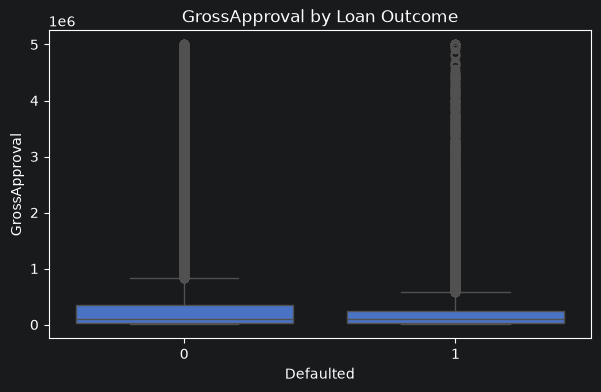

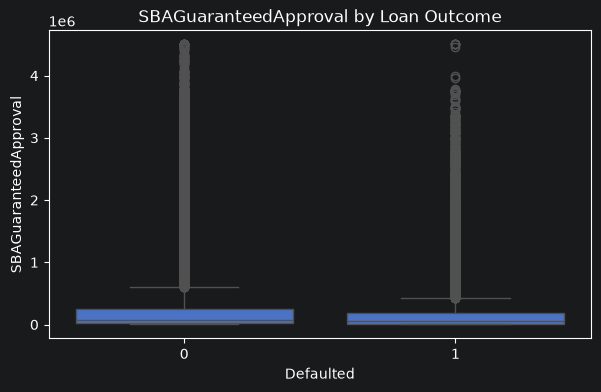

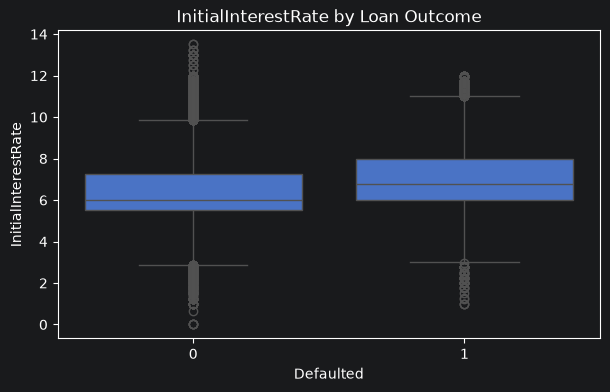

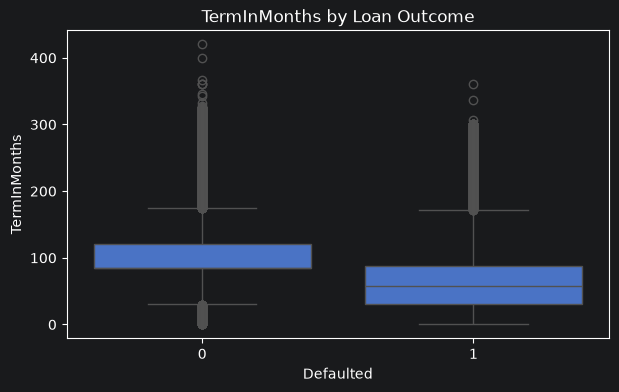

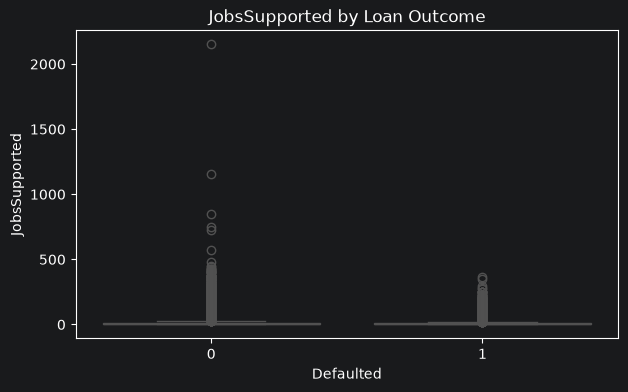

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=eda_df, x="default", y=col)
    plt.title(f"{col} by Loan Outcome")
    plt.xlabel("Defaulted")
    plt.ylabel(col)
    plt.show()

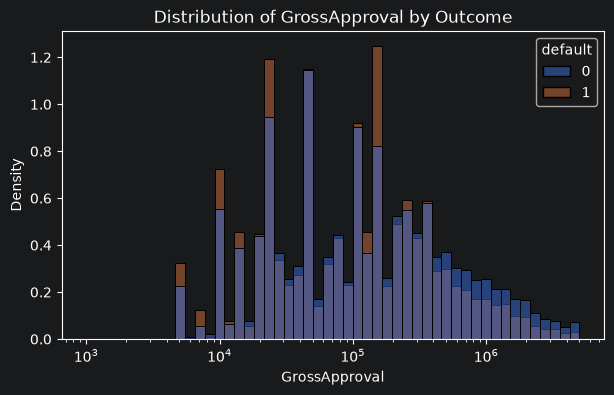

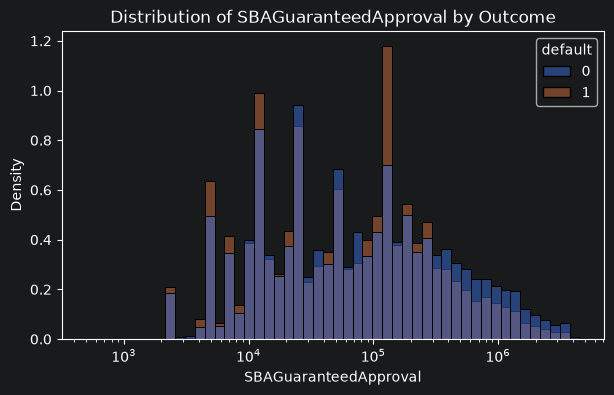

In [93]:
for col in ["GrossApproval", "SBAGuaranteedApproval"]:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=eda_df, x=col, hue="default", bins=50, log_scale=True, stat="density", common_norm=False)
    plt.title(f"Distribution of {col} by Outcome")
    plt.show()

In [94]:
eda_df["sba_guarantee_ratio"] = eda_df["SBAGuaranteedApproval"] / eda_df["GrossApproval"]
eda_df["naics_sector"] = eda_df["NaicsCode"].astype("Int64").astype(str).str[:2]

eda_df[["sba_guarantee_ratio", "naics_sector"]].head()

,sba_guarantee_ratio,naics_sector
0,0.9,72
1,0.9,54
2,0.9,31
3,0.5,72
5,0.5,23


In [95]:
eda_df.groupby("default")["sba_guarantee_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,394721.0,0.639565,0.151743,0.1300,0.5,0.50,0.75,0.9
1,34153.0,0.663494,0.159788,0.1025,0.5,0.75,0.85,1.0


In [96]:
sector_default_rate = (
    eda_df
    .groupby("naics_sector")["default"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

sector_default_rate.head(15)

,count,mean
naics_sector,,
92,75,0.106667
71,12290,0.105289
45,16330,0.102756
48,22152,0.095432
42,23149,0.091494
72,54678,0.088921
61,5837,0.086517
23,46162,0.085763
44,42205,0.085677


In [97]:
sector_default_rate[sector_default_rate["count"] >= 500].sort_values("mean", ascending=False).head(15)

,count,mean
naics_sector,,
71,12290,0.105289
45,16330,0.102756
48,22152,0.095432
42,23149,0.091494
72,54678,0.088921
61,5837,0.086517
23,46162,0.085763
44,42205,0.085677
49,1557,0.084778


In [98]:
cat_features = [
    "ProcessingMethod",
    "FixedorVariableInterestInd",
    "BusinessType",
    "BusinessAge",
    "RevolverStatus",
    "CollateralInd",
    "ProjectState"
]

for col in cat_features:
    summary = (
        eda_df
        .groupby(col)["default"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )
    display(summary.head(15))

,count,mean
ProcessingMethod,,
Community Advantage International Trade,3,0.333333
Community Express,5114,0.202777
Community Advantage Initiative,4096,0.169678
Patriot Express Loans,5512,0.134978
Gulf Opportunity Pilot Loan Program,1496,0.104947
Export Express,1169,0.100941
Small Loan Advantage Initiative,25631,0.100113
Rural Loan Initiative,2682,0.089858
International Trade Loans,1040,0.086538


,count,mean
FixedorVariableInterestInd,,
V,336182,0.087099
F,92692,0.052561


,count,mean
BusinessType,,
INDIVIDUAL,47371,0.083680
CORPORATION,373626,0.079788
PARTNERSHIP,7860,0.047201


,count,mean
BusinessAge,,
New Business or 2 years or less,19,0.473684
Existing or more than 2 years old,33502,0.099875
"Startup, Loan Funds will Open Business",63409,0.097194
Less than 3 years old but at least 2,23612,0.091733
"New, Less than 1 Year old",42936,0.087759
Less than 5 years old but at least 4,17402,0.085507
Unanswered,38298,0.081701
Less than 4 years old but at least 3,28010,0.078543
Change of Ownership,6130,0.071126


,count,mean
RevolverStatus,,
N,288236,0.081884
Y,140638,0.075022


,count,mean
CollateralInd,,
N,124631,0.103000
Y,304243,0.070062


,count,mean
ProjectState,,
MP,5,0.200000
FL,20340,0.122075
TX,32511,0.104334
SC,3216,0.103856
NJ,11240,0.103114
LA,3276,0.101038
IL,13892,0.098618
VA,6509,0.096021
AL,3019,0.094071


In [99]:
year_summary = (
    eda_df
    .groupby("ApprovalFY")["default"]
    .agg(["count", "mean"])
    .reset_index()
)

year_summary

,ApprovalFY,count,mean
0,2010,39276,0.093467
1,2011,44609,0.070524
2,2012,37756,0.064599
3,2013,38758,0.062490
4,2014,43889,0.067033
5,2015,52176,0.072773
6,2016,51449,0.079205
7,2017,47118,0.091833
8,2018,42237,0.101262
9,2019,31606,0.096722


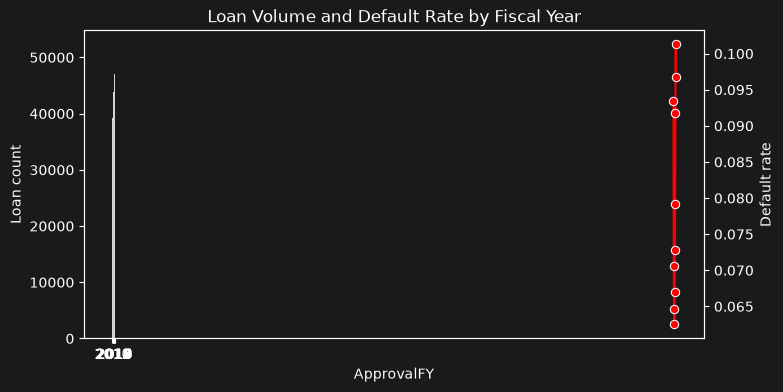

In [100]:
fig, ax1 = plt.subplots(figsize=(8, 4))

sns.barplot(data=year_summary, x="ApprovalFY", y="count", color="lightgray", ax=ax1)
ax1.set_ylabel("Loan count")

ax2 = ax1.twinx()
sns.lineplot(data=year_summary, x="ApprovalFY", y="mean", marker="o", color="red", ax=ax2)
ax2.set_ylabel("Default rate")

plt.title("Loan Volume and Default Rate by Fiscal Year")
plt.show()

In [101]:
target_cols = ["default"]

feature_decisions = pd.DataFrame({
    "column": eda_df.columns,
    "decision": [
        "target" if col in target_cols
        else "drop" if col in likely_drop_cols
        else "candidate"
        for col in eda_df.columns
    ]
})

feature_decisions

,column,decision
0,AsOfDate,drop
1,Program,drop
2,LocationID,drop
3,BorrName,drop
4,BorrStreet,drop
5,BorrCity,candidate
6,BorrState,candidate
7,BorrZip,drop
8,BankName,drop
9,BankFDICNumber,drop


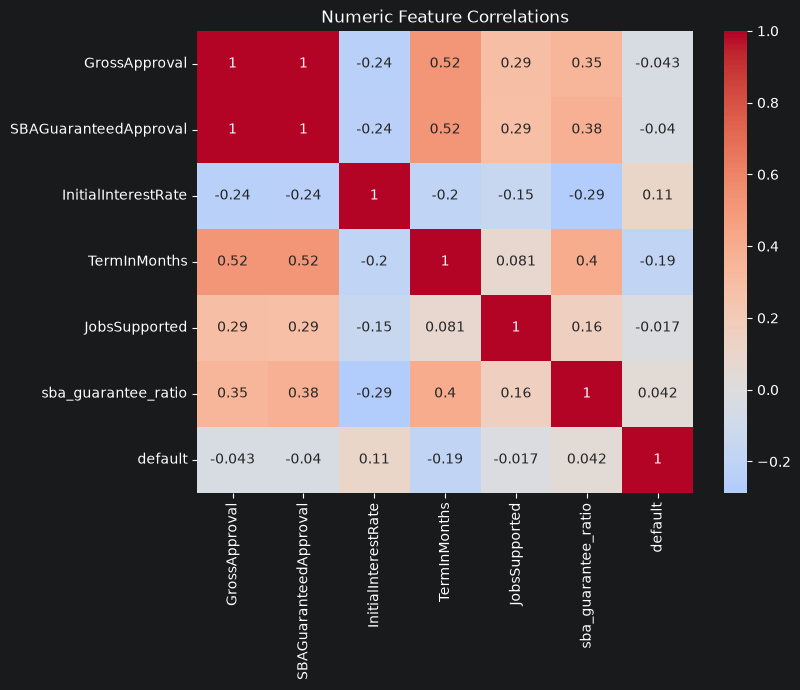

In [102]:
corr_cols = [
    "GrossApproval",
    "SBAGuaranteedApproval",
    "InitialInterestRate",
    "TermInMonths",
    "JobsSupported",
    "sba_guarantee_ratio",
    "default"
]

corr = eda_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlations")
plt.show()

## EDA Conclusions

For the first modeling version:

- The target will be binary:
  - `0`: paid in full (`P I F`)
  - `1`: charged off/default (`CHGOFF`)
- Rows with `CANCLD`, `EXEMPT`, and `COMMIT` will be excluded.
- Leakage columns will be removed before modeling:
  - `PaidInFullDate`
  - `ChargeOffDate`
  - `GrossChargeOffAmount`
  - `AsOfDate`
- High-cardinality identity/address fields will not be used in the first model.
- `FirstDisbursementDate` may not be available at approval time, so it will only be used if the prediction scenario is after disbursement. For the first model, I will exclude it or convert it carefully.
- `Program` will also be dropped because all rows are SBA 7(a), so it has no variation.
- Useful feature groups include:
  - Loan amount and SBA guarantee amount
  - Interest rate
  - Term length
  - Business age
  - Business type
  - Industry / NAICS sector
  - State
  - Collateral indicator
  - Revolver status
  - Jobs supported
- The next notebook will focus on cleaning these fields and creating a reusable processed dataset.